In [ ]:
#Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
#Memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/Praktikum-Tugas_MachineLearning/Praktikum7"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8')


In [ ]:
#Membaca file csv menggunakan pandas
df = pd.read_csv(path + '/Data/dataset_satelit.csv')
#Cetak header data (5 baris data) dari file
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [ ]:
# Konversi kolom Mg ke numerik
df['Mg'] = pd.to_numeric(df['Mg'], errors='coerce')

# Hapus kolom "No" bila ada
df = df.drop(columns=['No'], errors='ignore')

# Hapus baris kosong
df = df.dropna()

# Info final dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, 0 to 593
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  592 non-null    float64
 1   Lattitude  592 non-null    float64
 2   N          592 non-null    float64
 3   P          592 non-null    float64
 4   K          592 non-null    float64
 5   Ca         592 non-null    float64
 6   Mg         592 non-null    float64
 7   Fe         592 non-null    float64
 8   Mn         592 non-null    float64
 9   Cu         592 non-null    float64
 10  Zn         592 non-null    float64
 11  B          592 non-null    float64
 12  b12        592 non-null    float64
 13  b11        592 non-null    float64
 14  b9         592 non-null    float64
 15  b8a        592 non-null    float64
 16  b8         592 non-null    float64
 17  b7         592 non-null    float64
 18  b6         592 non-null    float64
 19  b5         592 non-null    float64
 20  b4         592 

In [ ]:
target = "N"

X = df.drop(columns=[target])
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Model
svr_model = SVR(kernel='rbf', C=100, gamma='scale')
linreg_model = LinearRegression()

# Training
svr_model.fit(X_train_scaled, y_train)
linreg_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_svr = svr_model.predict(X_test_scaled)
y_pred_lr = linreg_model.predict(X_test_scaled)

# Evaluasi
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== HASIL SVR ===")
print(f"RMSE: {rmse_svr:.4f}")
print(f"R2:   {r2_svr:.4f}")

print("\n=== HASIL Linear Regression ===")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R2:   {r2_lr:.4f}")


=== HASIL SVR ===
RMSE: 0.2418
R2:   0.6191

=== HASIL Linear Regression ===
RMSE: 0.1889
R2:   0.7675


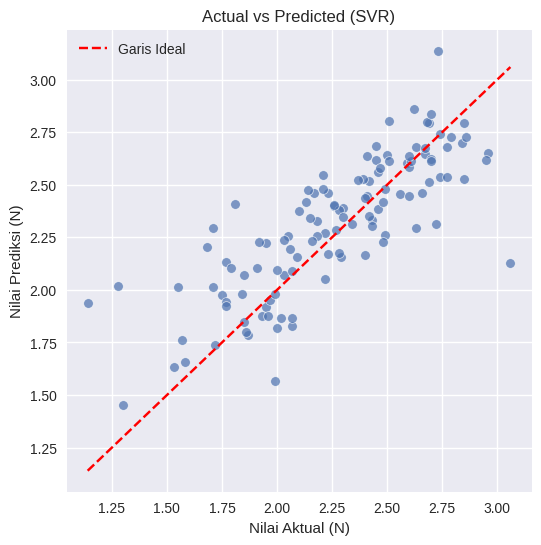

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_svr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Garis Ideal')

plt.xlabel("Nilai Aktual (N)")
plt.ylabel("Nilai Prediksi (N)")
plt.title("Actual vs Predicted (SVR)")
plt.legend()
plt.show()


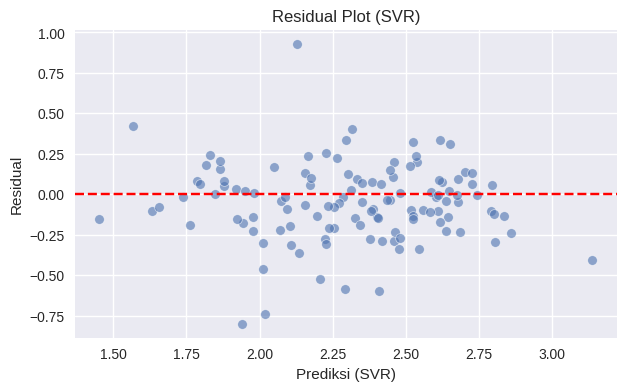

In [ ]:
residuals = y_test - y_pred_svr

plt.figure(figsize=(7,4))
sns.scatterplot(x=y_pred_svr, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Prediksi (SVR)")
plt.ylabel("Residual")
plt.title("Residual Plot (SVR)")
plt.show()


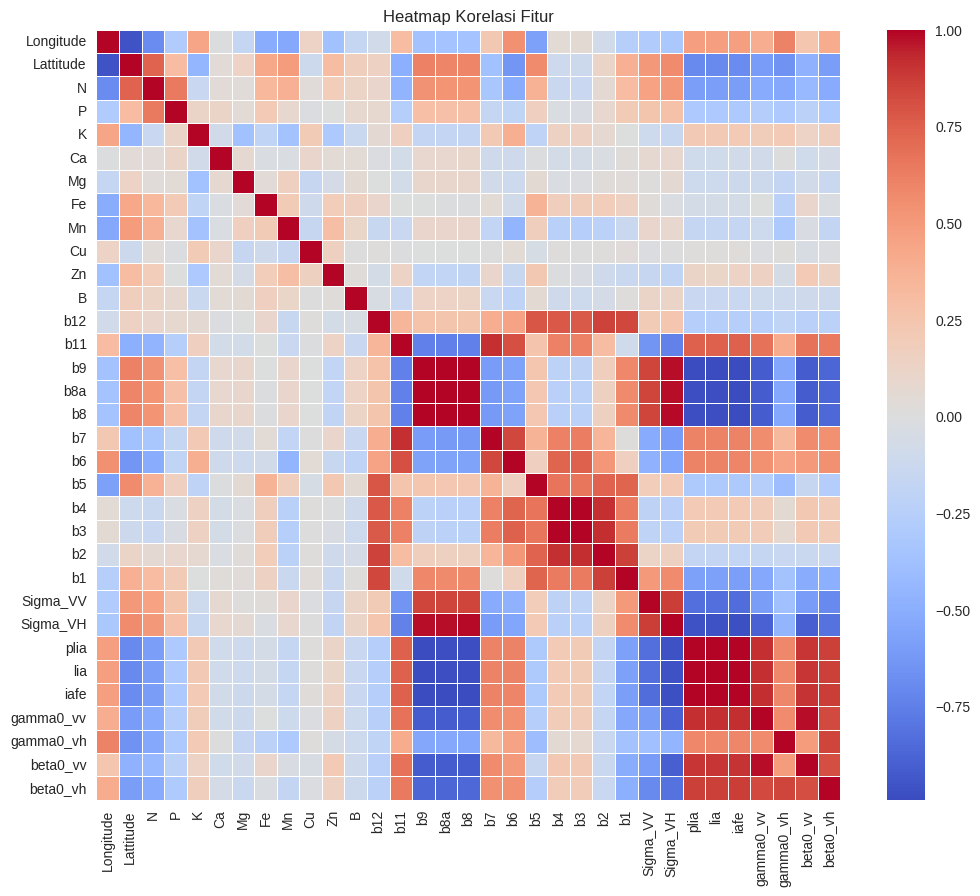

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=.5)
plt.title("Heatmap Korelasi Fitur")
plt.show()